# Modul A · Kapitel 1.2 — Lineare Regression

## Challenge: Baue ein Modell, das Hauspreise vorhersagt

**Lernziel:** Du kannst erklären, wie ein lineares Modell aufgebaut ist, wie man misst, ob es gut
ist — und du trainierst selbst eines, das Hauspreise vorhersagt.

Am Ende dieses Notebooks hast du ein funktionierendes Vorhersagemodell und weißt, was in jedem
seiner Bestandteile passiert.

### So funktioniert dieses Notebook

| Symbol | Bedeutung |
|:--:|---|
| 📖 | Erklärung — lesen |
| ▶️ | Fertiger Code — einfach ausführen (`Shift` + `Enter`) |
| 🛠️ | **Challenge** — hier schreibst du selbst Code |
| ✅ | Selbsttest — sagt dir sofort, ob deine Lösung stimmt |
| 💡 | **Lösung** — zum Aufklappen, wenn du nicht weiterkommst |
| 💬 | Diskussionsfrage — kurz überlegen, gerne mit der Nachbarin / dem Nachbarn |

**Wichtig:** Führe die Zellen **von oben nach unten** aus. Spätere Zellen brauchen die
Funktionen, die du vorher schreibst.

Es sind **7 Challenges**. Wer schneller fertig ist, findet am Ende ein Bonus-Notebook.

---
## 0 · Setup

▶️ Führe diese zwei Zellen aus. Danach sind alle Werkzeuge geladen und die Daten liegen bereit.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Einheitliche Farben für alle Diagramme in diesem Notebook
BLAU, ORANGE, TEAL, GRAU = "#2563eb", "#e8590c", "#0d9488", "#6b7280"

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": GRAU,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#e5e7eb",
    "grid.linewidth": 0.8,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "font.size": 11,
})
np.set_printoptions(suppress=True, precision=2)

print("Setup fertig ✔")

Setup fertig ✔


In [15]:
def lade_daten(dateiname):
    """Liest eine der Workshop-CSVs ein — lokal oder in Google Colab."""
    kandidaten = [
        Path(dateiname),
        Path("data") / dateiname,
        Path("..") / "data" / dateiname,
        Path("challenges/lineare-regression/data") / dateiname,
    ]
    for pfad in kandidaten:
        if pfad.exists():
            print(f"Gelesen: {pfad}")
            return pd.read_csv(pfad)

    # Google Colab: Datei von Hand hochladen
    try:
        from google.colab import files
        print(f"'{dateiname}' nicht gefunden — bitte jetzt hochladen:")
        files.upload()
        return pd.read_csv(dateiname)
    except ImportError:
        raise FileNotFoundError(
            f"'{dateiname}' nicht gefunden. Lege die CSV neben dieses Notebook."
        )


df = lade_daten("haus_preise_einfach.csv")
df.head()

Gelesen: data/haus_preise_einfach.csv


,wohnflaeche_qm,preis_usd
0,109.6,221900
1,238.8,538000
2,71.5,180000
3,182.1,604000
4,156.1,510000


---
## 1 · Die Daten

📖 Wir arbeiten mit **echten Verkaufsdaten**: 21.613 Häuser, die 2014 und 2015 im King County
(die Gegend um Seattle) verkauft wurden.

Für den Anfang reichen uns zwei Spalten:

| Spalte | Bedeutung |
|---|---|
| `wohnflaeche_qm` | Wohnfläche in Quadratmetern |
| `preis_usd` | tatsächlicher Verkaufspreis in US-Dollar |

Genau das ist **Supervised Learning** aus Kapitel 1.1: Zu jedem Beispiel (Wohnfläche) steht die
richtige Antwort (Preis) daneben. Unsere Aufgabe ist eine **Regression** — wir sagen eine Zahl
vorher, keine Kategorie.

In [16]:
print(f"Zeilen (Häuser): {len(df)}")
print(f"Spalten: {list(df.columns)}")
df.describe()

Zeilen (Häuser): 21613
Spalten: ['wohnflaeche_qm', 'preis_usd']


,wohnflaeche_qm,preis_usd
count,21613.000000,2.161300e+04
mean,193.229496,5.400881e+05
std,85.326202,3.671272e+05
min,26.900000,7.500000e+04
25%,132.600000,3.219500e+05
50%,177.400000,4.500000e+05
75%,236.900000,6.450000e+05
max,1257.900000,7.700000e+06


Bevor man rechnet, schaut man sich die Daten an.

*Tipp: `df["spaltenname"].mean()`, `.max()`, und `len(df)`.*

In [17]:
anzahl_haeuser = len(df)
durchschnittspreis = df["preis_usd"].mean()
groesstes_haus = df["wohnflaeche_qm"].max()
teuerstes_haus = df["preis_usd"].max()

print(f"{anzahl_haeuser} Häuser")
print(f"Durchschnittspreis: {durchschnittspreis:,.0f} USD")
print(f"Größtes Haus: {groesstes_haus} m²")
print(f"Teuerstes Haus: {teuerstes_haus:,.0f} USD")

21613 Häuser
Durchschnittspreis: 540,088 USD
Größtes Haus: 1257.9 m²
Teuerstes Haus: 7,700,000 USD


---
## 2 · Erst schauen, dann rechnen

📖 Ein Modell zu trainieren, ohne die Daten gesehen zu haben, ist wie ein Rezept zu kochen,
ohne die Zutaten zu kennen. Zuerst also: hinschauen.

Zwei Diagramme reichen dafür fast immer:

| Diagramm | Beantwortet | Braucht |
|---|---|---|
| **Histogramm** | Wie verteilt sich **eine** Spalte? | 1 Spalte |
| **Streudiagramm** | Hängen **zwei** Spalten zusammen? | 2 Spalten |

### 📊 Das Histogramm

Ein Histogramm zerlegt eine Spalte in gleich breite Abschnitte (*bins*) und zählt, wie viele
Werte in jeden Abschnitt fallen. Die Höhe eines Balkens ist also keine Größe, sondern eine
**Anzahl**.

Damit siehst du auf einen Blick: Wo liegen die typischen Werte? Wie breit streuen sie? Ist die
Verteilung symmetrisch — oder hat sie einen langen Ausläufer zu einer Seite? Gibt es Ausreißer?

▶️ **Beispiel — die Wohnfläche.** Führe die Zelle aus und schau dir den Code an: Genau eine
Zeile zeichnet (`ax.hist(...)`), alles andere ist Beschriftung.

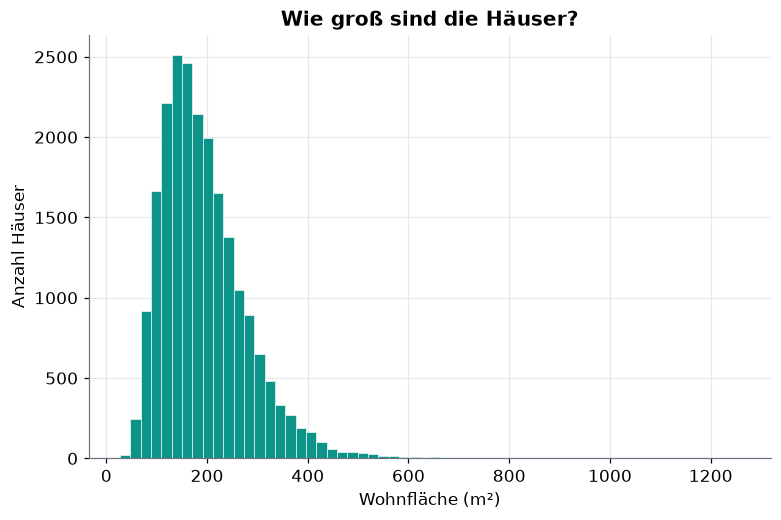

In [18]:
fig, ax = plt.subplots()

ax.hist(df["wohnflaeche_qm"], bins=60, color=TEAL, edgecolor="white", linewidth=0.4)

ax.set_xlabel("Wohnfläche (m²)")
ax.set_ylabel("Anzahl Häuser")
ax.set_title("Wie groß sind die Häuser?")
plt.show()

### 🛠️ Challenge 1 — Das Histogramm der Preise

Jetzt du: Erstelle ein Histogramm für die Spalte **`preis_usd`**.

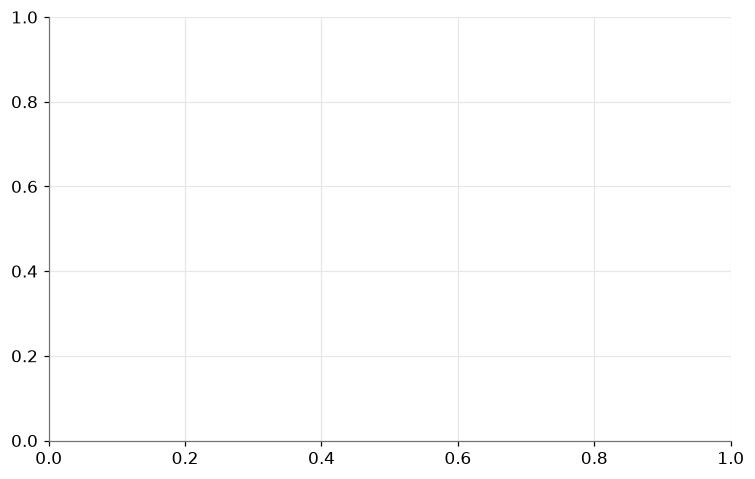

In [27]:
fig, ax = plt.subplots()

...

plt.show()

<details>
<summary>💡 Lösung aufklappen — erst selbst probieren!</summary>

```python
obergrenze = 2200   # Tausend USD
ausserhalb = (df["preis_usd"] / 1000 > obergrenze).sum()

fig, ax = plt.subplots()
ax.hist(df["preis_usd"] / 1000, bins=400, color=BLAU, edgecolor="white", linewidth=0.4)
ax.set_xlim(0, obergrenze)
ax.set_xlabel("Preis (Tausend USD)")
ax.set_ylabel("Anzahl Häuser")
ax.set_title("Die meisten Häuser kosten 300–600 Tsd. USD")
ax.axvline(df["preis_usd"].mean() / 1000, color=ORANGE, linewidth=2)
ax.text(df["preis_usd"].mean() / 1000 + 40, ax.get_ylim()[1] * 0.88,
        f"Mittelwert\n{df['preis_usd'].mean()/1000:,.0f} Tsd.", color=ORANGE)
ax.text(obergrenze * 0.55, ax.get_ylim()[1] * 0.5,
        f"{ausserhalb} teure Häuser liegen\nrechts außerhalb des Bildes", color=GRAU, fontsize=9)
plt.show()
```

</details>

### 📈 Das Streudiagramm

Ein Histogramm zeigt immer nur **eine** Spalte. Unsere eigentliche Frage braucht aber zwei:
Hängt der Preis mit der Wohnfläche zusammen?

Genau dafür gibt es das **Streudiagramm** (*scatter plot*): Jede Zeile der Tabelle wird zu einem
Punkt — die eine Spalte bestimmt die x-Position, die andere die y-Position. Zieht sich die
Punktwolke von links unten nach rechts oben, hängen die beiden Spalten zusammen. Und genau diese
Wolke wird unser Modell gleich mit einer Geraden nachzeichnen.

### 🛠️ Challenge 2 — Das Streudiagramm aller Häuser

Jetzt du: Erstelle ein Streudiagramm mit den spalten **`wohnflaeche_qm`** und **`preis_usd`**.

Tipp: Viele Punkte liegen übereinander, du siehst sonst nur einen blauen
Klumpen? Deshalb zeichnen wir sie kleiner und durchsichtig:

* `s=6` — die Punktgröße
* `alpha=0.25` — die Deckkraft (0 = unsichtbar, 1 = voll deckend)

Wo viele Punkte übereinanderliegen, wird es dadurch von selbst dunkler.

*Tipp: `ax.scatter(x, y, s=6, alpha=0.25, color=BLAU, linewidths=0)`*

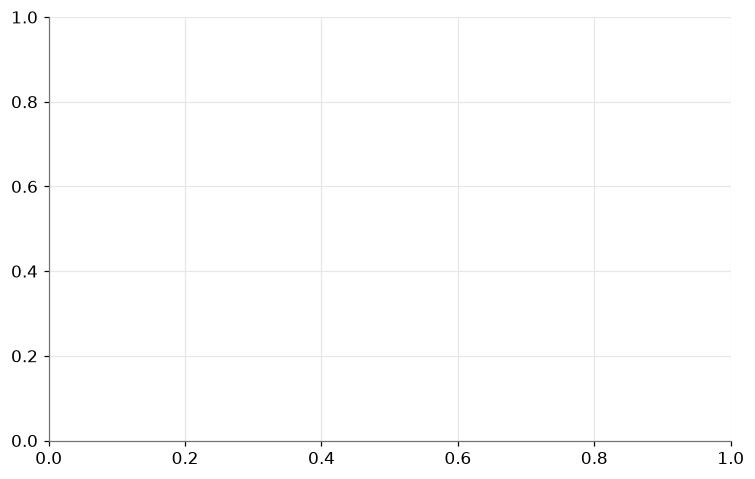

In [28]:
fig, ax = plt.subplots()

...

plt.show()

<details>
<summary>💡 Lösung aufklappen — erst selbst probieren!</summary>

```python
fig, ax = plt.subplots()

ax.scatter(df["wohnflaeche_qm"], df["preis_usd"], s=6, alpha=0.25, color=BLAU, linewidths=0)

ax.set_xlabel("Wohnfläche (m²)")
ax.set_ylabel("Preis (USD)")
ax.set_title("Größer = teurer?")
plt.show()
```

</details>

---
## 3 · Trainings- und Testdaten trennen

📖 Ein Modell, das man auf denselben Daten prüft, mit denen man es trainiert hat, ist wie eine
Prüfung, bei der man die Fragen vorher kennt. Das Ergebnis sagt nichts darüber aus, ob das
Modell auch bei **neuen** Häusern funktioniert.

Deshalb teilen wir die Daten auf, **bevor** wir irgendetwas rechnen:

* **80 % Trainingsdaten** — daraus lernt das Modell.
* **20 % Testdaten** — die sieht das Modell erst ganz am Ende. Einmal. Zum Prüfen.

▶️ Ausführen. Die Zufallszahl `42` sorgt dafür, dass alle im Raum dieselbe Aufteilung bekommen.

In [ ]:
zufall = np.random.default_rng(42)
gemischt = zufall.permutation(len(df))
grenze = int(0.8 * len(df))

train = df.iloc[gemischt[:grenze]]
test = df.iloc[gemischt[grenze:]]

# .to_numpy() macht aus den Pandas-Spalten einfache Zahlenreihen (NumPy-Arrays)
x_train = train["wohnflaeche_qm"].to_numpy()
y_train = train["preis_usd"].to_numpy().astype(float)
x_test = test["wohnflaeche_qm"].to_numpy()
y_test = test["preis_usd"].to_numpy().astype(float)

print(f"Training: {len(x_train)} Häuser")
print(f"Test:     {len(x_test)} Häuser")

---
## 4 · Das Modell

📖 Unser Modell ist eine Gerade:

$$\text{preis} = w \cdot \text{wohnflaeche} + b$$

* $w$ (*weight*, Gewicht) ist die **Steigung**: Wie viele Dollar kostet ein zusätzlicher Quadratmeter?
* $b$ (*bias*) ist der **Achsenabschnitt**: Wo startet die Gerade?

Das ist exakt die Formel aus der Präsentation.

**Trainieren heißt nichts anderes als: gute Zahlen für $w$ und $b$ finden.**

### 🛠️ Challenge 3 — Die Vorhersage

Schreibe die Funktion, die aus Wohnfläche, $w$ und $b$ einen Preis berechnet.

Tipp: Du musst im Grunde die Formel von unserem Modell implementieren.

In [29]:
def vorhersage(x, w, b):
    """Berechnet den vorhergesagten Preis für eine oder viele Wohnflächen."""
    # TODO: Ersetze die nächste Zeile durch die Formel
    raise NotImplementedError("Challenge 3: vorhersage() implementieren")

In [30]:
# ✅ Selbsttest
assert vorhersage(100, 3000, -40000) == 260000
assert vorhersage(0, 3000, -40000) == -40000
assert np.allclose(vorhersage(np.array([50.0, 100.0]), 3000, -40000), [110000, 260000])
print("✅ Challenge 3 gelöst")

NotImplementedError: Challenge 3: vorhersage() implementieren

<details>
<summary>💡 Lösung aufklappen — erst selbst probieren!</summary>

```python
def vorhersage(x, w, b):
    """Berechnet den vorhergesagten Preis für eine oder viele Wohnflächen."""
    return w * x + b
```

Mehr ist es nicht — das ist das ganze Modell. 

</details>

▶️ Jetzt raten wir einfach mal drei Geraden und schauen, welche am besten passt.

NameError: name 'x_train' is not defined

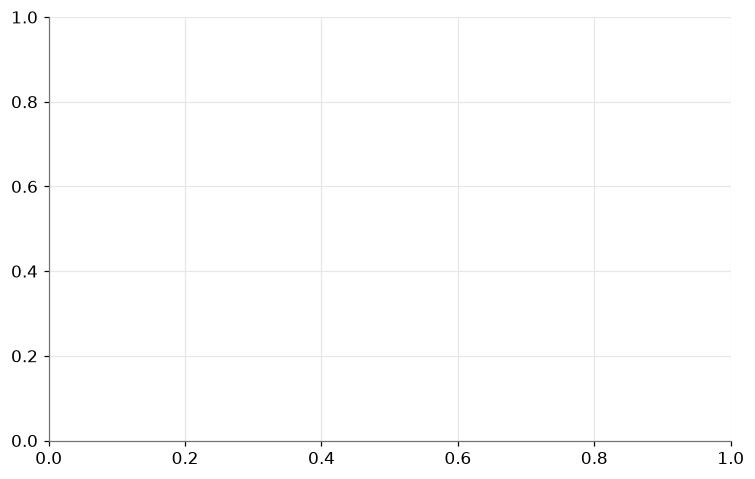

In [31]:
kandidaten = [(1000, 0), (3000, 0), (5000, -200000)]
farben = [GRAU, BLAU, ORANGE]

fig, ax = plt.subplots()
ax.scatter(x_train, y_train, s=6, alpha=0.15, color="#94a3b8", linewidths=0)

x_linie = np.array([x_train.min(), x_train.max()])
for (w, b), farbe in zip(kandidaten, farben):
    ax.plot(x_linie, vorhersage(x_linie, w, b), color=farbe, linewidth=2,
            label=f"w = {w}, b = {b}")

ax.set_xlabel("Wohnfläche (m²)")
ax.set_ylabel("Preis (USD)")
ax.set_title("Welche Gerade ist die beste?")
ax.set_ylim(0, 3_000_000)
ax.legend()
plt.show()

💬 Welche der drei Geraden ist die beste? Und vor allem: **Woher wollen wir das wissen?**

Solange wir nur schauen, ist "gut" Geschmackssache. Wir brauchen eine **Zahl**, die misst,
wie falsch ein Modell liegt.

---
## 5 · Die Kostenfunktion: Wie falsch liegen wir?

📖 Für jedes Haus können wir den Fehler ausrechnen:

$$\text{fehler} = \text{vorhersage} - \text{echter Preis}$$

Diese Fehler wollen wir zu **einer** Zahl zusammenfassen. Drei Überlegungen:

1. **Einfach aufsummieren geht nicht** — plus 50.000 und minus 50.000 würden sich zu 0 aufheben,
   obwohl das Modell zweimal danebenlag.
2. Wir **quadrieren** die Fehler. Damit hebt sich ein Fehler von plus 50.000 und minus 50.000 nicht auf und große Abweichungen werden stärker bestraft als kleinere Abweichungen. 
3. Wir bilden den **Mittelwert**, damit die Zahl nicht von der Anzahl der Häuser abhängt.

Das Ergebnis heißt **Mean Squared Error (MSE)**:

$$\text{MSE} = \frac{1}{n}\sum_{i=1}^{n}\left(\hat{y}_i - y_i\right)^2$$

Diese Zahl ist unsere **Kostenfunktion**. Trainieren bedeutet diese Zahl so klein wie möglich machen.

### 🛠️ Challenge 4 — Mean Squared Error

*Tipp: Mit NumPy brauchst du keine Schleife. `(a - b) ** 2` rechnet elementweise,
`np.mean(...)` mittelt.*

In [ ]:
def mse(y_wahr, y_vorhersage):
    """Mittlerer quadratischer Fehler zwischen echten und vorhergesagten Preisen."""
    # TODO
    raise NotImplementedError("Challenge 4: mse() implementieren")

In [ ]:
# ✅ Selbsttest
assert mse(np.array([1.0, 2.0, 3.0]), np.array([1.0, 2.0, 3.0])) == 0.0
assert mse(np.array([0.0, 0.0]), np.array([2.0, 4.0])) == 10.0
assert mse(np.array([10.0, 20.0]), np.array([12.0, 18.0])) == 4.0
print("✅ Challenge 4 gelöst")

<details>
<summary>💡 Lösung aufklappen — erst selbst probieren!</summary>

```python
def mse(y_wahr, y_vorhersage):
    """Mittlerer quadratischer Fehler zwischen echten und vorhergesagten Preisen."""
    return float(np.mean((y_vorhersage - y_wahr) ** 2))
```

Von innen nach außen gelesen: Differenz bilden, quadrieren, mitteln — genau die drei
Überlegungen von oben, in einer Zeile. `float(...)` macht aus dem NumPy-Ergebnis nur eine
normale Python-Zahl, damit sie sich schön ausgeben lässt.

Wenn du `y_wahr` und `y_vorhersage` vertauscht hast: kein Problem. Durch das Quadrat kommt
dasselbe heraus.

</details>

In [ ]:
# ▶️ Und was sagt der MSE über unsere drei geratenen Geraden?
for w, b in kandidaten:
    kosten = mse(y_train, vorhersage(x_train, w, b))
    print(f"w = {w:>5}, b = {b:>8}  →  MSE = {kosten:,.0f}")

📖 Fällt dir etwas auf? Die Zahlen sind **astronomisch groß** — kein Wunder, wir haben
Dollar-Beträge quadriert. Aus "200.000 USD daneben" werden 40.000.000.000. Damit kann niemand
etwas anfangen.

Die Lösung: einmal die **Wurzel** ziehen. Dann sind wir wieder in Dollar. Das Ergebnis heißt
**Root Mean Squared Error (RMSE)**:

$$\text{RMSE} = \sqrt{\text{MSE}} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}\left(\hat{y}_i - y_i\right)^2}$$

Der RMSE heißt ungefähr: *"So weit liegt das Modell typischerweise daneben."* Zum **Trainieren**
ändert er nichts — wo der MSE am kleinsten ist, ist auch seine Wurzel am kleinsten. Aber zum
**Verstehen** ist er unschlagbar: Eine Zahl in Dollar kannst du jemandem erklären, 69 Milliarden
quadrierte Dollar nicht.

### 🛠️ Challenge 5 — Root Mean Squared Error

Schreibe die Funktion, die aus echten und vorhergesagten Preisen den RMSE berechnet.

*Tipp*: `mse()` hast du schon.

In [ ]:
def rmse(y_wahr, y_vorhersage):
    """Wurzel aus dem mittleren quadratischen Fehler — in USD."""
    # TODO
    raise NotImplementedError("Challenge 5: rmse() implementieren")

In [ ]:
# ✅ Selbsttest
assert rmse(np.array([1.0, 2.0, 3.0]), np.array([1.0, 2.0, 3.0])) == 0.0
assert rmse(np.array([0.0, 0.0]), np.array([3.0, 3.0])) == 3.0
assert rmse(np.array([10.0, 20.0]), np.array([12.0, 18.0])) == 2.0
print("✅ Challenge 5 gelöst")

<details>
<summary>💡 Lösung aufklappen — erst selbst probieren!</summary>

```python
def rmse(y_wahr, y_vorhersage):
    """Wurzel aus dem mittleren quadratischen Fehler — in USD."""
    return float(np.sqrt(mse(y_wahr, y_vorhersage)))
```

Eine Zeile — und sie benutzt deine eigene `mse()`-Funktion weiter. Genau so baut man Software:
kleine Bausteine, die aufeinander aufsetzen.

</details>

In [ ]:
# ▶️ Dieselben drei Geraden — jetzt in Dollar
for w, b in kandidaten:
    fehler = rmse(y_train, vorhersage(x_train, w, b))
    print(f"w = {w:>5}, b = {b:>8}  →  RMSE = {fehler:>10,.0f} USD")

print()
print("Auch die beste der drei liegt im Schnitt über 260.000 USD daneben.")

▶️ Jetzt probieren wir nicht drei, sondern 200 Werte für $w$ durch und zeichnen die Kosten:

In [32]:
w_werte = np.linspace(0, 6000, 200)
kosten_werte = [rmse(y_train, vorhersage(x_train, w, 0.0)) for w in w_werte]
bestes_w = w_werte[int(np.argmin(kosten_werte))]

fig, ax = plt.subplots()
ax.plot(w_werte, kosten_werte, color=BLAU, linewidth=2)
ax.scatter([bestes_w], [min(kosten_werte)], color=ORANGE, s=60, zorder=3)
ax.annotate(f"bestes w ≈ {bestes_w:,.0f} USD/m²",
            xy=(bestes_w, min(kosten_werte)), xytext=(bestes_w + 250, min(kosten_werte) * 1.8),
            color=ORANGE, arrowprops=dict(arrowstyle="->", color=ORANGE))
ax.set_xlabel("w  (USD pro m²)")
ax.set_ylabel("RMSE  (USD)")
ax.set_title("Die Kostenlandschaft ist eine Schüssel (b = 0 festgehalten)")
plt.show()

NameError: name 'mse' is not defined

📖 **Das ist die zentrale Idee.** Die Kostenfunktion bildet eine Schüssel, und gesucht ist ihr
tiefster Punkt.

In diesem Bild haben wir $b = 0$ festgehalten und nur $w$ variiert. In Wirklichkeit suchen wir
**zwei** Zahlen gleichzeitig — die Schüssel ist also eine Fläche im Raum, und wir suchen die
tiefste Stelle darin.

---
## 6 · Den tiefsten Punkt finden: Gradientenabstieg

📖 Wie findet man diesen tiefsten Punkt? 

Das Standardverfahren heißt **Gradientenabstieg** (*gradient descent*):

> Stell dir vor, du auf einem Berg und willst ins Tal. Du siehst das Tal nicht, weil es nebelig ist. 
> In welche Richtung geht es **abwärts**? Du machst einen Schritt dorthin.
> Dann wieder. Und wieder. So tastest du dich ins Tal, ohne es je zu sehen.

Genau so lernt jedes neuronale Netz und jedes LLM: viele kleine Schritte.

**Die gute Nachricht: Diesen Algorithmus müssen wir nicht selbst schreiben.** 

Dafür gibt es `scikit-learn` — die Standardbibliothek für klassisches Machine Learning in Python. 

Zwei Zeilen, und das Minimum ist gefunden.

▶️ Trainieren wir also unser erstes Modell:

In [1]:
from sklearn.linear_model import LinearRegression

modell = LinearRegression()
# `.reshape(-1, 1)` macht aus der einfachen Zahlenreihe eine Tabelle mit einer Spalte.
# `scikit-learn` erwartet immer eine Tabelle (Zeilen × Merkmale), auch bei nur einem Merkmal.
# `.fit(...)` ist das Training.
modell.fit(x_train.reshape(-1, 1), y_train)

# Die gelernten Gewichte stehen in `modell.coef_`
w_trainiert = modell.coef_[0]
# Und der Bias (y-Achsenabschnitt) in `modell.intercept_`
b_trainiert = modell.intercept_

print(f"w = {w_trainiert:,.2f} USD pro m²")
print(f"b = {b_trainiert:,.2f} USD")
print()
print(f"Dein Modell: Preis = {w_trainiert:,.2f} · Wohnfläche  {b_trainiert:+,.2f}")

NameError: name 'x_train' is not defined

In [ ]:
print(f"{'Modell':<34}{'MSE (Trainingsdaten)':>24}")
print("-" * 58)
for w, b in kandidaten:
    beschriftung = f"geraten: w={w}, b={b}"
    print(f"{beschriftung:<34}{mse(y_train, vorhersage(x_train, w, b)):>24,.0f}")
print(f"{'scikit-learn':<34}{mse(y_train, vorhersage(x_train, w_trainiert, b_trainiert)):>24,.0f}")
print()
print("Kein geratener Wert kommt näher heran — das ist der tiefste Punkt der Schüssel.")

In [ ]:
fig, ax = plt.subplots()
ax.scatter(x_train, y_train, s=6, alpha=0.15, color="#94a3b8", linewidths=0, label="verkaufte Häuser")

x_linie = np.array([x_train.min(), x_train.max()])
ax.plot(x_linie, vorhersage(x_linie, w_trainiert, b_trainiert), color=ORANGE, linewidth=2.5,
        label=f"trainiertes Modell ({w_trainiert:,.0f} USD/m²)")

ax.set_xlabel("Wohnfläche (m²)")
ax.set_ylabel("Preis (USD)")
ax.set_title("Dein trainiertes Modell")
ax.set_ylim(0, 3_000_000)
ax.legend()
plt.show()

💡 **Genau genommen:** Für die lineare Regression rechnet `scikit-learn` das Minimum sogar mit
einer exakten Formel aus, ganz ohne Schrittchen — bei so einem kleinen Modell geht das. Sobald
ein Modell größer wird (neuronales Netz, LLM), gibt es diese Formel nicht mehr, und
Gradientenabstieg ist der einzige praktikable Weg. Deshalb lohnt es sich, das Verfahren zu
kennen, das Ergebnis ist in beiden Fällen dasselbe.

---
## 7 · Dein Modell im Einsatz

📖 Dein trainiertes Modell besteht aus genau **zwei Zahlen**: `w_trainiert` und `b_trainiert`.
Mehr braucht es nicht, um für jedes beliebige Haus einen Preis zu schätzen — und die Funktion
dafür hast du in Challenge 3 selbst geschrieben.

### 🛠️ Challenge 6 — Ein Haus kommt auf den Markt

📬 Dieses Exposé landet heute in deinem Postfach:

> **🏡 Charmantes Familienhaus in Ballard, Seattle**
>
> 165 m² Wohnfläche · 480 m² Grundstück · 4 Zimmer, 2 Bäder · Baujahr 1998, Bad 2015
> renoviert · Garage, Südgarten, Kamin · ruhige Seitenstraße, Grundschule in 5 Gehminuten
>
> *Preisvorstellung: auf Anfrage*

**Was ist dieses Haus laut deinem Modell wert?** Rechne den Preis auf beide Arten aus:

1. mit deiner eigenen `vorhersage()`-Funktion aus Challenge 3,
2. mit `modell.predict(...)` von `scikit-learn`.

*Tipp zu 2: `.predict()` erwartet immer eine Tabelle von Häusern, also `[[165.0]]` — eine Zeile
mit einem Merkmal. Das Ergebnis ist eine Liste, du brauchst davon das erste Element `[0]`.*

In [ ]:
wohnflaeche_neu = 165.0

# TODO 1: mit deiner eigenen Funktion
preis_eigene_funktion = ...

# TODO 2: mit scikit-learn
preis_sklearn = ...

print(f"Deine Funktion: {preis_eigene_funktion:,.2f} USD")
print(f"scikit-learn:   {preis_sklearn:,.2f} USD")

In [ ]:
# ✅ Selbsttest
assert abs(preis_eigene_funktion - 455_551) < 5, "Erwartet werden rund 455.551 USD"
assert np.isclose(preis_eigene_funktion, preis_sklearn), "Beide Wege müssen dasselbe liefern"
print(f"✅ Challenge 6 gelöst — dein Modell schätzt das Haus auf {preis_eigene_funktion:,.0f} USD 🎉")

<details>
<summary>💡 Lösung aufklappen — erst selbst probieren!</summary>

```python
wohnflaeche_neu = 165.0

preis_eigene_funktion = vorhersage(wohnflaeche_neu, w_trainiert, b_trainiert)

preis_sklearn = modell.predict([[wohnflaeche_neu]])[0]

print(f"Deine Funktion: {preis_eigene_funktion:,.2f} USD")
print(f"scikit-learn:   {preis_sklearn:,.2f} USD")
```

Beide Wege liefern auf den Cent dasselbe — und das ist der Punkt: `modell.predict()` macht
nichts anderes als deine drei Zeichen `w * x + b`.

</details>

In [ ]:
# ▶️ Zum Spielen: eigene Flächen einsetzen und ausführen
for flaeche in [80, 120, 165, 250, 400]:
    print(f"{flaeche:>4} m²  →  {vorhersage(flaeche, w_trainiert, b_trainiert):>10,.0f} USD")

💬 Der Makler ruft an: **"Aber das Bad nie renoviert
worden wäre und das Dach ist beschädigt?"**

Dein Modell nennt **exakt denselben Preis**. Es hat nie etwas anderes gesehen als die
Wohnfläche — Grundstück, Baujahr, Zustand, Lage: davon stand nichts in `x_train`.

Ein Modell kann nur benutzen, was man ihm gibt. Zwei Häuser mit 165 m² bekommen denselben Preis,
egal ob Villa am See oder Reihenhaus an der Schnellstraße. Mit mehr relevante Merkmalen kann man noch viel genauere Vorherssagen machen. 

---
## 8 · Die ehrliche Prüfung: die Testdaten

📖 Alles, was wir bisher gerechnet haben, lief auf den **Trainingsdaten** — genau den Häusern,
aus denen das Modell seine zwei Zahlen gelernt hat. Ein kleiner Fehler ist dort ungefähr so
aussagekräftig wie eine Klausur, deren Aufgaben man vorher gesehen hat.

Jetzt — und erst jetzt — holen wir die **Testdaten** aus Abschnitt 3 hervor. Diese 4.323 Häuser
hat das Modell nie gesehen. Sie sind die einzige ehrliche Antwort auf die Frage: Taugt das was?

### 🛠️ Challenge 7 — Wie gut ist dein Modell wirklich?

Miss den Fehler deines Modells auf den **Testdaten** — mit deiner eigenen `rmse()`-Funktion aus
Challenge 5.

1. Vorhersagen für alle Testhäuser berechnen.
2. Den RMSE zwischen `y_test` und diesen Vorhersagen bestimmen.

*Tipp zu 1: Beide Wege funktionieren — `modell.predict(x_test.reshape(-1, 1))` oder deine eigene
`vorhersage(x_test, w_trainiert, b_trainiert)`.*

In [ ]:
# TODO 1: Vorhersagen für alle Testhäuser
y_test_vorhersage = ...

# TODO 2: RMSE auf den Testdaten
rmse_test = ...

rmse_train = rmse(y_train, vorhersage(x_train, w_trainiert, b_trainiert))
print(f"RMSE auf den Trainingsdaten: {rmse_train:>10,.0f} USD")
print(f"RMSE auf den Testdaten:      {rmse_test:>10,.0f} USD")

In [ ]:
# ✅ Selbsttest
assert len(y_test_vorhersage) == len(y_test), "Für jedes Testhaus eine Vorhersage"
assert abs(rmse_test - 265_763) < 500, "Erwartet werden rund 265.800 USD"
print("✅ Challenge 7 gelöst")

<details>
<summary>💡 Lösung aufklappen — erst selbst probieren!</summary>

```python
y_test_vorhersage = modell.predict(x_test.reshape(-1, 1))

rmse_test = rmse(y_test, y_test_vorhersage)
```

`x_test.reshape(-1, 1)` aus demselben Grund wie beim Training: `scikit-learn` will eine Tabelle,
keine Zahlenreihe. Und deine `rmse()`-Funktion interessiert es überhaupt nicht, ob die Zahlen aus
Trainings- oder Testdaten stammen — sie rechnet einfach.

</details>

💬 Training 260.356 USD, Test 265.763 USD — praktisch derselbe Fehler. Warum ist das eine gute
Nachricht, und was wäre das Alarmsignal gewesen?

<details>
<summary>Antwort aufklappen</summary>

Gute Nachricht: Das Modell hat nichts **auswendig gelernt**. Auf fremden Häusern funktioniert es
genauso wie auf den bekannten.

Das Alarmsignal wäre der umgekehrte Fall: winziger Fehler im Training, großer im Test. Dann hätte
sich das Modell die Trainingsdaten gemerkt, statt eine Regel zu lernen — **Overfitting**. Unser
Modell *kann* das gar nicht: Es besteht aus zwei Zahlen, da ist kein Platz, um sich 17.290 Häuser
zu merken. Je größer ein Modell wird, desto realer wird die Gefahr — bei einem LLM mit Milliarden
Parametern ist sie das zentrale Thema.

Genau deshalb trennt man die Daten **vorher**, nicht hinterher: Wer erst am Ende entscheidet,
worauf er misst, misst sich die Welt schön.
</details>

---
## 9 · Was du gebaut hast

1. **Daten angeschaut**, bevor du gerechnet hast — und gesehen, dass eine Gerade hier nie
   perfekt passen kann.
2. **Train/Test getrennt**, damit die Bewertung am Ende ehrlich bleibt.
3. **Das Modell** $w \cdot x + b$ selbst geschrieben.
4. **Die Kostenfunktion** MSE selbst geschrieben — die Zahl, die „gut" überhaupt erst definiert —
   und mit dem RMSE eine Fassung, die man aussprechen kann.
5. **Ein Modell trainiert, angewendet und ehrlich bewertet.**

---
# 🎉 Fertig!

Du hast ein Modell gebaut, das Hauspreise vorhersagt. Und jetzt? Such dir aus, worauf du Lust
hast:

### 🏠 Mehr Merkmale
`bonus_mehrere_merkmale_challenge.ipynb`

Ein Haus ist mehr als seine Fläche. Nimm Bauqualität und Baujahr dazu und schau, wie viel besser
das Modell wird — und was die gelernten Zahlen über den Immobilienmarkt von Seattle verraten.

### ⚙️ Unter die Haube
`bonus_gradientenabstieg_challenge.ipynb`

Wie findet `scikit-learn` eigentlich den tiefsten Punkt der Schüssel? Bau den Gradientenabstieg
selbst — denselben Algorithmus, mit dem auch neuronale Netze und LLMs trainiert werden.

### ☕ Oder einfach: Kaffee
Lehn dich zurück, während die anderen fertig werden. Und wenn du magst: schau mal nach links und
rechts. Jemandem beim Debuggen zu helfen ist die beste Art, selbst zu merken, ob man es
verstanden hat.